Data Loaded Successfully!
Dataset Shape: (200, 5)



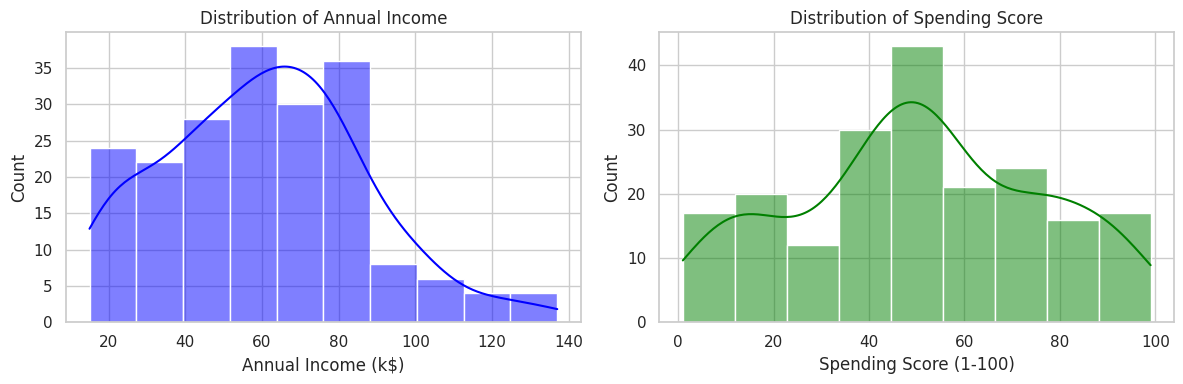

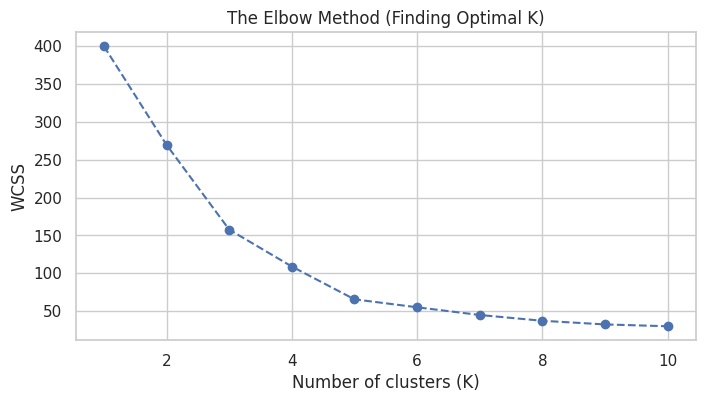

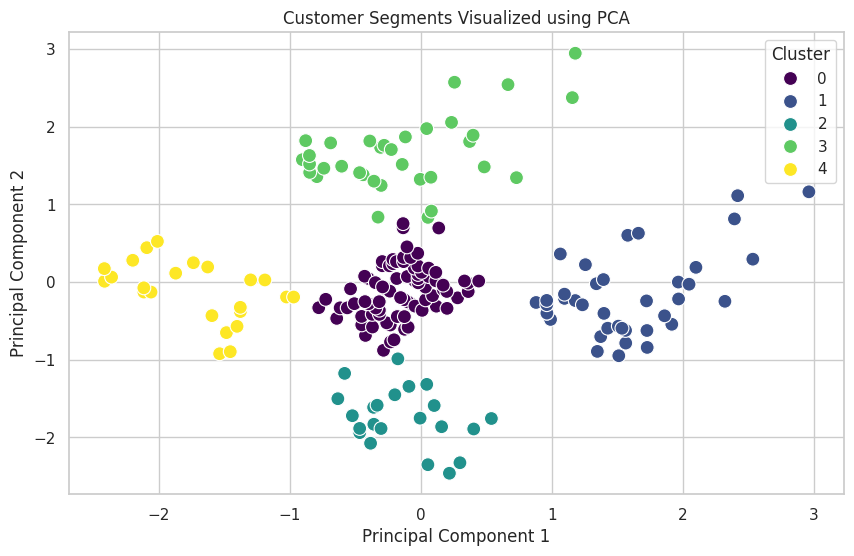


🎯 MARKETING STRATEGIES FOR EACH SEGMENT

Cluster 0: Average Income, Average Spenders
- Strategy: Regular marketing aur basic loyalty programs offer karein.

Cluster 1: High Income, Low Spenders (Careful)
- Strategy: Inko premium ya exclusive products dikhayen jo inka trust jeet sakain aur value for money lagain.

Cluster 2: Low Income, Low Spenders (Sensible)
- Strategy: Discount offers aur clearance sales ke ishteharaat bhejein.

Cluster 3: High Income, High Spenders (Target/VIP)
- Strategy: Ye mall ke sab se behtareen customers hain. Inhe naye arrivals aur VIP memberships offer karein.

Cluster 4: Low Income, High Spenders (Careless/Trendsetters)
- Strategy: Inko trendy aur affordable cheezein dikhayen, inke liye flash sales behtareen rahengi.



In [1]:
# --- ADVANCED TASK 2: CUSTOMER SEGMENTATION USING UNSUPERVISED LEARNING ---
# Objective: Cluster customers based on spending habits and propose marketing strategies.

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 2. LOAD DATASET
# Hum Mall Customers dataset directly GitHub se load kar rahe hain
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)
print("Data Loaded Successfully!")
print(f"Dataset Shape: {df.shape}\n")

# 3. EXPLORATORY DATA ANALYSIS (EDA)
# CustomerID drop kar rahe hain kyunki ye analysis ke liye zaroori nahi hai
df.drop('CustomerID', axis=1, inplace=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Annual Income (k$)'], kde=True, color='blue')
plt.title('Distribution of Annual Income')

plt.subplot(1, 2, 2)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='green')
plt.title('Distribution of Spending Score')
plt.tight_layout()
plt.show()

# 4. PREPARE DATA FOR K-MEANS
# Sirf Annual Income aur Spending Score le rahe hain taake achi clustering ho
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Data ko scale karna zaroori hai K-Means ke liye
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method (Optimal K nikalne ke liye)
# WCSS (Within-Cluster Sum of Square) calculate karte hain
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method (Finding Optimal K)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

# 5. K-MEANS CLUSTERING (K=5)
# Graph (Elbow) ke mutabiq 5 clusters sab se behtar hain
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Original dataframe mein Cluster ka column add kar rahe hain
df['Cluster'] = clusters

# 6. DIMENSIONALITY REDUCTION (PCA) & VISUALIZATION
# Instructions mein PCA manga gaya hai. Hum data ko 2 principal components mein reduce karenge.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis', s=100)
plt.title('Customer Segments Visualized using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# 7. MARKETING STRATEGIES (Business Intelligence)
print("\n" + "="*60)
print("🎯 MARKETING STRATEGIES FOR EACH SEGMENT")
print("="*60)

print("""
Cluster 0: Average Income, Average Spenders
- Strategy: Regular marketing aur basic loyalty programs offer karein.

Cluster 1: High Income, Low Spenders (Careful)
- Strategy: Inko premium ya exclusive products dikhayen jo inka trust jeet sakain aur value for money lagain.

Cluster 2: Low Income, Low Spenders (Sensible)
- Strategy: Discount offers aur clearance sales ke ishteharaat bhejein.

Cluster 3: High Income, High Spenders (Target/VIP)
- Strategy: Ye mall ke sab se behtareen customers hain. Inhe naye arrivals aur VIP memberships offer karein.

Cluster 4: Low Income, High Spenders (Careless/Trendsetters)
- Strategy: Inko trendy aur affordable cheezein dikhayen, inke liye flash sales behtareen rahengi.
""")